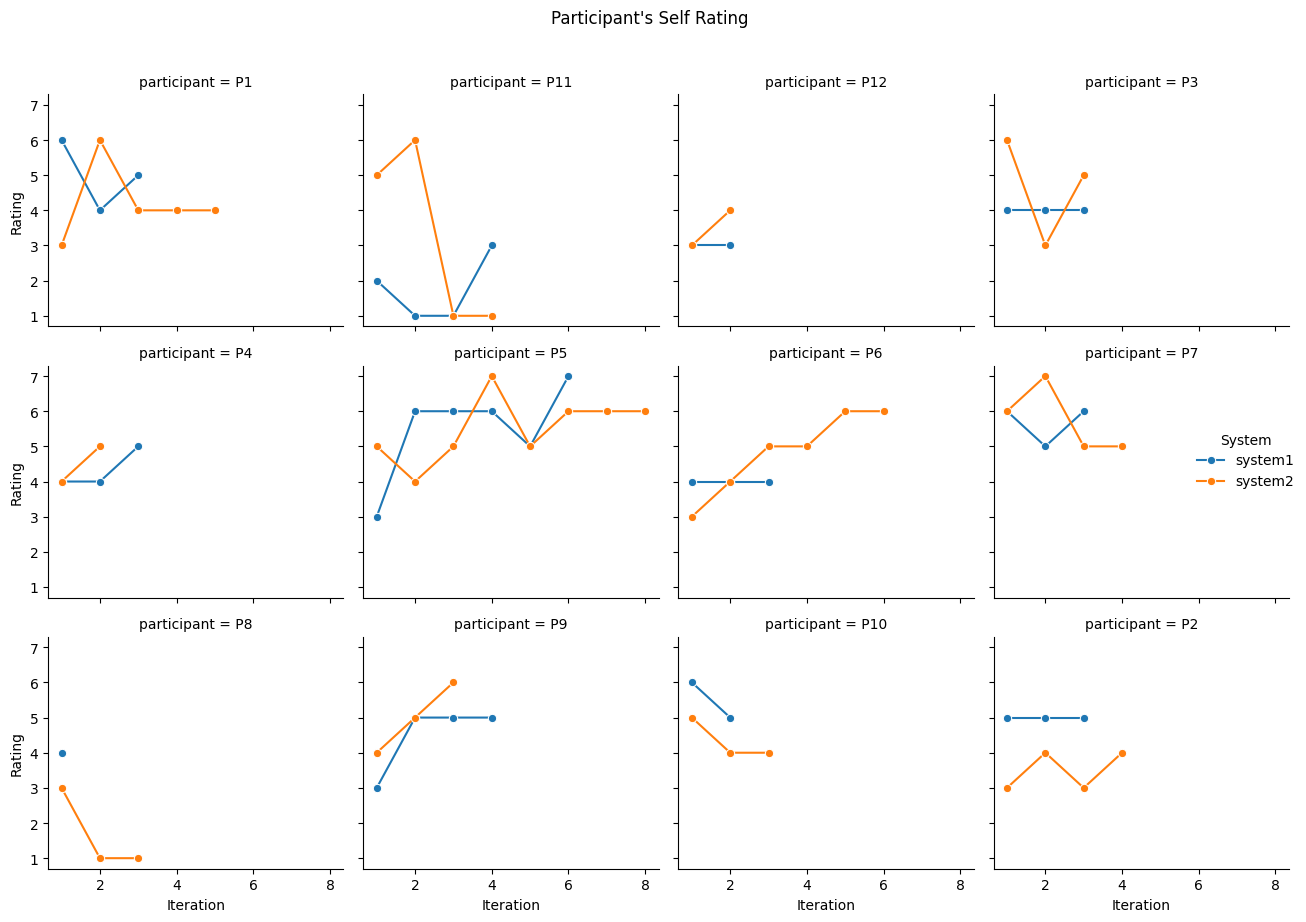

In [1]:
# participant/system별로 row 순서대로 iteration 번호 부여 후, SSIM/rating 변화 시각화
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('result/ssim/image_rating_ssim.csv')

# 각 participant/system별로 순서대로 iteration 번호 부여
df['iteration'] = df.groupby(['participant', 'system']).cumcount() + 1

# 2. Rating 변화: participant별, system별, iteration별
g2 = sns.FacetGrid(
    df, col='participant', hue='system',
    col_wrap=4, height=3, sharey=True,
    palette={'system1':'#1f77b4','system2':'#ff7f0e'}
)
g2.map(sns.lineplot, 'iteration', 'rating', marker='o')
g2.add_legend(title='System')
g2.set_axis_labels('Iteration', 'Rating')
g2.fig.suptitle('Participant\'s Self Rating', y=1.02)
plt.tight_layout()
plt.show()
g2.add_legend(title='System')
g2.set_axis_labels('Iteration', 'Rating')
g2.set(ylim=(1,7))   # ✅ 모든 subplot y축을 1–7로 고정


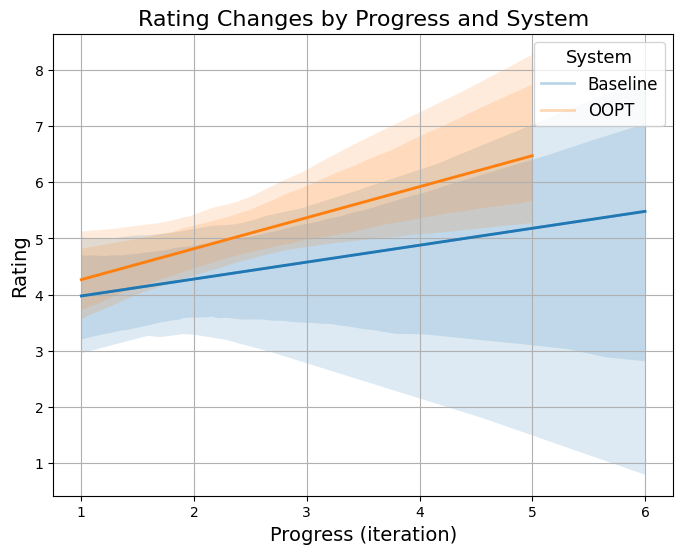

In [2]:
## Hyeon

progress = []
rating = []
system = []
participant = []  # ✅ 추가

for p_idx in range(1, 13):
    participant_id = f"P{p_idx}"
    p_idx_df = df[df["participant"] == participant_id]
    ratings_system1 = p_idx_df[p_idx_df["system"] == "system1"]["rating"].tolist()
    ratings_system2 = p_idx_df[p_idx_df["system"] == "system2"]["rating"].tolist()

    ratings_system1_max_value_idx = ratings_system1.index(max(ratings_system1)) if ratings_system1 else -1
    ratings_system2_max_value_idx = ratings_system2.index(max(ratings_system2)) if ratings_system2 else -1

    ratings_system1 = ratings_system1[:ratings_system1_max_value_idx+1] if ratings_system1_max_value_idx != -1 else []
    ratings_system2 = ratings_system2[:ratings_system2_max_value_idx+1] if ratings_system2_max_value_idx != -1 else []
    
    for i in range(len(ratings_system1)):
        progress.append(i+1)
        rating.append(ratings_system1[i])
        system.append("system1")
        participant.append(participant_id)  # ✅ 참가자 저장
    
    for i in range(len(ratings_system2)):
        progress.append(i+1)
        rating.append(ratings_system2[i])
        system.append("system2")
        participant.append(participant_id)  # ✅ 참가자 저장

df_viz = pd.DataFrame({
    "participant": participant,  # ✅ 새로운 column
    "progress": progress,
    "rating": rating,
    "system": system
})

plt.figure(figsize=(8, 6))

# 원하는 색상 팔레트
palette = {"Baseline": "#1f77b4", "OOPT": "#ff7f0e"}

# system 이름 매핑
name_map = {"system1": "Baseline", "system2": "OOPT"}

for sys, new_name in name_map.items():
    color = palette[new_name]
    sub = df_viz[df_viz["system"] == sys]
    
    # 바깥쪽 99.5% CI
    sns.regplot(
        data=sub, x="progress", y="rating", scatter=False,
        ci=99.5, line_kws={"lw":2, "alpha":0.3, "color":color},
        color=color, label=new_name  # legend label 지정
    )
    
    # 안쪽 95% CI
    sns.regplot(
        data=sub, x="progress", y="rating", scatter=False,
        ci=95, line_kws={"lw":2, "alpha":1, "color":color},
        color=color
    )

plt.title("Rating Changes by Progress and System", fontsize=16)
plt.xlabel("Progress (iteration)", fontsize=14)
plt.ylabel("Rating", fontsize=14)
plt.grid(True)
plt.legend(title="System", fontsize=12, title_fontsize=13)
plt.show()


=== Δrating (final - first) : Paired stats (P5 excluded) ===
{'n_pairs': 11, 't': -2.32379000772445, 'p_t': 0.04249750171368153, 'W': 0.0, 'p_w': 0.03843393023678171, 'cohens_d': 0.7006490497453708}

=== Δ per iteration : Paired stats (P5 excluded) ===
{'n_pairs': 7, 't': -5.52679423766206, 'p_t': 0.001477563705031964, 'W': 0.0, 'p_w': 0.015625, 'cohens_d': 2.0889318714683744}


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Sample size too small for normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_66983/3921066823.py:115: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y1 = float(sub.loc[sub["system"]=="system1", "delta_rating"])
/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_66983/3921066823.py:116: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) i

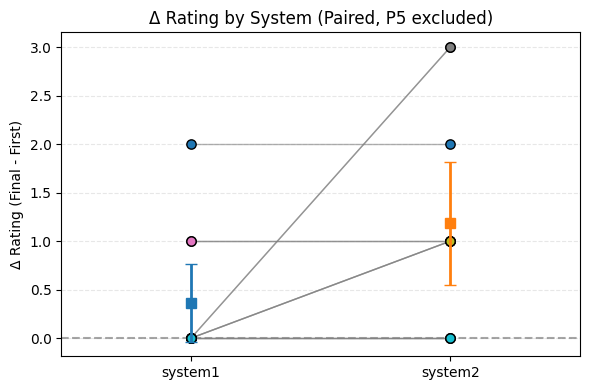

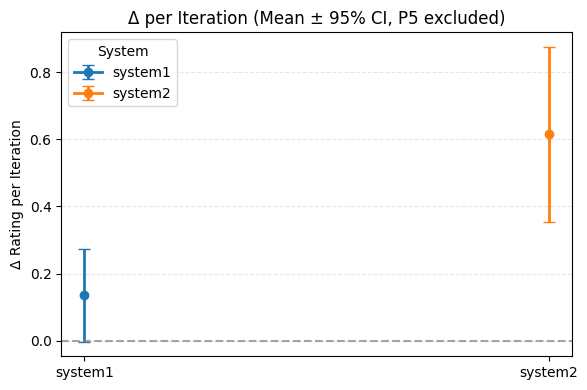


=== System-level summary (P5 excluded) ===
    system  first_mean  final_mean  delta_mean  delta_iter_mean   n
0  system1       4.273       4.636       0.364            0.135  11
1  system2       4.091       5.273       1.182            0.615  11


In [3]:
# -*- coding: utf-8 -*-
# 간단 분석 스크립트: first vs final, Δrating/Δ per iter, P5 제외, 통계 + 그래프
# 경로만 맞춰서 실행하세요.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

# ---------------------------
# 0) 경로 설정
# ---------------------------
RATINGS_CSV = Path("result/ssim/image_rating_ssim.csv")        # iteration별 로그(처음~끝)
FINAL_CSV   = Path("output_final/final_outputs_mapping.csv")   # 최종 산출물 매핑

# ---------------------------
# 1) 데이터 로드
# ---------------------------
df_all   = pd.read_csv(RATINGS_CSV)    # 필요한 컬럼: participant, system, rating, (iteration 없으면 생성)
df_final = pd.read_csv(FINAL_CSV)      # 필요한 컬럼: participant, system_type, rating, iter_number, (iter_time 있으면 사용)

# iteration 없으면 부여
if "iteration" not in df_all.columns:
    df_all = df_all.sort_values(["participant","system"]).copy()
    df_all["iteration"] = df_all.groupby(["participant","system"]).cumcount() + 1

# 타입 정리
df_all["iteration"] = df_all["iteration"].astype(int)
df_all["rating"]    = pd.to_numeric(df_all["rating"], errors="coerce")

# ---------------------------
# 2) first / final 뽑기
# ---------------------------
# first rating (participant × system)
first = (df_all.sort_values("iteration")
               .groupby(["participant","system"], as_index=False)
               .first()[["participant","system","rating"]]
               .rename(columns={"rating":"first_rating"}))

# final rating/iter/time (participant × system_type)
use_cols = ["participant","system_type","rating","iter_number"]
if "iter_time" in df_final.columns:
    use_cols.append("iter_time")
elif "rating_timestamp" in df_final.columns:
    use_cols.append("rating_timestamp")  # 참고용

final = (df_final[use_cols]
           .groupby(["participant","system_type"], as_index=False)
           .last()
           .rename(columns={"system_type":"system",
                            "rating":"final_rating",
                            "iter_number":"final_iter"}))

# ---------------------------
# 3) 병합 + 파생변수
# ---------------------------
merged = pd.merge(first, final, on=["participant","system"], how="inner")

# P5 제외 (참가자 라벨이 숫자인 경우도 방지)
def is_P5(x):
    s = str(x).strip()
    return s == "P5" or s == "5"

merged = merged[~merged["participant"].apply(is_P5)].copy()

# Δrating, Δ per iter (iter=1이면 NaN)
merged["delta_rating"]   = merged["final_rating"] - merged["first_rating"]
merged["delta_per_iter"] = merged.apply(
    lambda r: np.nan if pd.isna(r["final_iter"]) or r["final_iter"] <= 1
    else r["delta_rating"] / r["final_iter"],
    axis=1
)

# ---------------------------
# 4) 통계 (paired: system1 vs system2)
# ---------------------------
def paired_tests(df, value_col):
    pivot = df.pivot(index="participant", columns="system", values=value_col)
    pivot = pivot[["system1","system2"]].dropna()
    if pivot.empty:
        return None
    t, p = stats.ttest_rel(pivot["system1"], pivot["system2"])
    # Wilcoxon은 0차이가 많으면 경고가 날 수 있음
    try:
        w, wp = stats.wilcoxon(pivot["system1"], pivot["system2"])
    except Exception:
        w, wp = (np.nan, np.nan)
    diff = pivot["system2"] - pivot["system1"]
    d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) > 0 else np.nan
    return {
        "n_pairs": len(pivot),
        "t": t, "p_t": p,
        "W": w, "p_w": wp,
        "cohens_d": d
    }

stats_delta = paired_tests(merged, "delta_rating")
stats_dpi   = paired_tests(merged, "delta_per_iter")

print("\n=== Δrating (final - first) : Paired stats (P5 excluded) ===")
print(stats_delta)
print("\n=== Δ per iteration : Paired stats (P5 excluded) ===")
print(stats_dpi)

# ---------------------------
# 5) 그래프 ① Paired dot plot (개인별 Δrating, system1↔system2 연결)
# ---------------------------
fig, ax = plt.subplots(figsize=(6,4))
# x 위치: system1=0, system2=1
xpos = {"system1":0, "system2":1}
# 점과 선
for pid, sub in merged.groupby("participant"):
    if set(sub["system"]) >= {"system1","system2"}:
        y1 = float(sub.loc[sub["system"]=="system1", "delta_rating"])
        y2 = float(sub.loc[sub["system"]=="system2", "delta_rating"])
        ax.plot([xpos["system1"], xpos["system2"]], [y1, y2], color="gray", alpha=0.6, linewidth=1)
        ax.scatter([xpos["system1"], xpos["system2"]], [y1, y2], s=45, edgecolors="k", zorder=3)

# 평균과 95% CI (덧그리기)
def mean_ci(y):
    y = np.asarray(y, dtype=float)
    y = y[~np.isnan(y)]
    m = np.mean(y)
    se = np.std(y, ddof=1) / np.sqrt(len(y)) if len(y) > 1 else 0.0
    ci95 = 1.96 * se
    return m, ci95

for sys, x in xpos.items():
    y = merged.loc[merged["system"]==sys, "delta_rating"].values
    m, ci = mean_ci(y)
    ax.errorbar([x], [m], yerr=[ci], fmt="s", ms=7, capsize=4, lw=2, zorder=4)

ax.axhline(0, ls="--", color="gray", alpha=0.7)
ax.set_xticks([0,1]); ax.set_xticklabels(["system1","system2"])
ax.set_ylabel("Δ Rating (Final - First)")
ax.set_title("Δ Rating by System (Paired, P5 excluded)")
ax.set_xlim(-0.5, 1.5)
ax.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------
# 6) 그래프 ② 평균 + 95% CI 막대/포인트 (Δ per iter, 색상 적용)
# ---------------------------
fig, ax = plt.subplots(figsize=(6,4))
colors = {"system1":"#1f77b4", "system2":"#ff7f0e"}
labels = ["system1","system2"]

for i, lab in enumerate(labels):
    y = merged.loc[merged["system"]==lab, "delta_per_iter"].values
    m, ci = mean_ci(y)
    ax.errorbar([i], [m], yerr=[ci], fmt="o-", lw=2, ms=6, capsize=4,
                color=colors[lab], label=lab)

ax.set_xticks([0,1]); ax.set_xticklabels(labels)
ax.set_ylabel("Δ Rating per Iteration")
ax.set_title("Δ per Iteration (Mean ± 95% CI, P5 excluded)")
ax.axhline(0, ls="--", color="gray", alpha=0.7)
ax.grid(True, axis="y", linestyle="--", alpha=0.3)
ax.legend(title="System")
plt.tight_layout()
plt.show()


# ---------------------------
# 7) 간단 요약 테이블 출력
# ---------------------------
summary = (merged.groupby("system", as_index=False)
                 .agg(first_mean=("first_rating","mean"),
                      final_mean=("final_rating","mean"),
                      delta_mean=("delta_rating","mean"),
                      delta_iter_mean=("delta_per_iter","mean"),
                      n=("participant","nunique")))
print("\n=== System-level summary (P5 excluded) ===")
print(summary.round(3))


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Sample size too small for normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_66983/2358715196.py:115: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y1 = float(sub.loc[sub["system"]=="system1", "delta_rating"])
/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_66983/2358715196.py:116: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) i


=== Δrating (final - first) : Paired stats (P5 included) ===
{'n_pairs': 12, 't': -1.1055415967851334, 'p_t': 0.292518455395773, 'W': 5.0, 'p_w': 0.2382692693463746, 'cohens_d': 0.3191423692521127}

=== Δ per iteration : Paired stats (P5 included) ===
{'n_pairs': 8, 't': -1.8477388207401697, 'p_t': 0.10712192208567599, 'W': 8.0, 'p_w': 0.1953125, 'cohens_d': 0.6532743250035041}


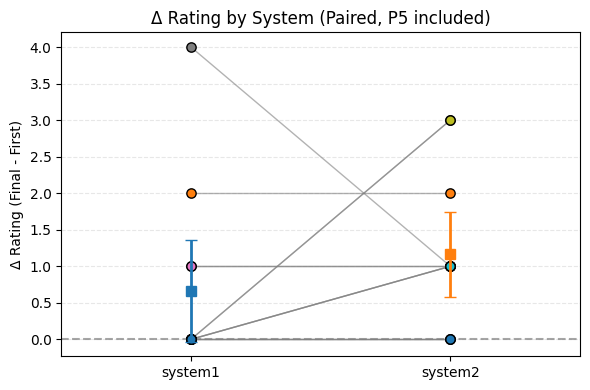

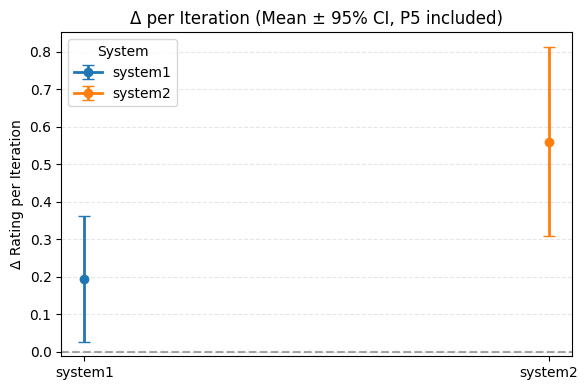


=== System-level summary (P5 included) ===
    system  first_mean  final_mean  delta_mean  delta_iter_mean   n
0  system1       4.167       4.833       0.667            0.194  12
1  system2       4.167       5.333       1.167            0.560  12


In [4]:
# -*- coding: utf-8 -*-
# 간단 분석 스크립트: first vs final, Δrating/Δ per iter, P5 제외, 통계 + 그래프
# 경로만 맞춰서 실행하세요.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

# ---------------------------
# 0) 경로 설정
# ---------------------------
RATINGS_CSV = Path("result/ssim/image_rating_ssim.csv")        # iteration별 로그(처음~끝)
FINAL_CSV   = Path("output_final/final_outputs_mapping.csv")   # 최종 산출물 매핑

# ---------------------------
# 1) 데이터 로드
# ---------------------------
df_all   = pd.read_csv(RATINGS_CSV)    # 필요한 컬럼: participant, system, rating, (iteration 없으면 생성)
df_final = pd.read_csv(FINAL_CSV)      # 필요한 컬럼: participant, system_type, rating, iter_number, (iter_time 있으면 사용)

# iteration 없으면 부여
if "iteration" not in df_all.columns:
    df_all = df_all.sort_values(["participant","system"]).copy()
    df_all["iteration"] = df_all.groupby(["participant","system"]).cumcount() + 1

# 타입 정리
df_all["iteration"] = df_all["iteration"].astype(int)
df_all["rating"]    = pd.to_numeric(df_all["rating"], errors="coerce")

# ---------------------------
# 2) first / final 뽑기
# ---------------------------
# first rating (participant × system)
first = (df_all.sort_values("iteration")
               .groupby(["participant","system"], as_index=False)
               .first()[["participant","system","rating"]]
               .rename(columns={"rating":"first_rating"}))

# final rating/iter/time (participant × system_type)
use_cols = ["participant","system_type","rating","iter_number"]
if "iter_time" in df_final.columns:
    use_cols.append("iter_time")
elif "rating_timestamp" in df_final.columns:
    use_cols.append("rating_timestamp")  # 참고용

final = (df_final[use_cols]
           .groupby(["participant","system_type"], as_index=False)
           .last()
           .rename(columns={"system_type":"system",
                            "rating":"final_rating",
                            "iter_number":"final_iter"}))

# ---------------------------
# 3) 병합 + 파생변수
# ---------------------------
merged = pd.merge(first, final, on=["participant","system"], how="inner")

# P5 제외 (참가자 라벨이 숫자인 경우도 방지)
def is_P5(x):
    s = str(x).strip()
    return s == "P5" or s == "5"

# merged = merged[~merged["participant"].apply(is_P5)].copy()

# Δrating, Δ per iter (iter=1이면 NaN)
merged["delta_rating"]   = merged["final_rating"] - merged["first_rating"]
merged["delta_per_iter"] = merged.apply(
    lambda r: np.nan if pd.isna(r["final_iter"]) or r["final_iter"] <= 1
    else r["delta_rating"] / r["final_iter"],
    axis=1
)

# ---------------------------
# 4) 통계 (paired: system1 vs system2)
# ---------------------------
def paired_tests(df, value_col):
    pivot = df.pivot(index="participant", columns="system", values=value_col)
    pivot = pivot[["system1","system2"]].dropna()
    if pivot.empty:
        return None
    t, p = stats.ttest_rel(pivot["system1"], pivot["system2"])
    # Wilcoxon은 0차이가 많으면 경고가 날 수 있음
    try:
        w, wp = stats.wilcoxon(pivot["system1"], pivot["system2"])
    except Exception:
        w, wp = (np.nan, np.nan)
    diff = pivot["system2"] - pivot["system1"]
    d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) > 0 else np.nan
    return {
        "n_pairs": len(pivot),
        "t": t, "p_t": p,
        "W": w, "p_w": wp,
        "cohens_d": d
    }

stats_delta = paired_tests(merged, "delta_rating")
stats_dpi   = paired_tests(merged, "delta_per_iter")

print("\n=== Δrating (final - first) : Paired stats (P5 included) ===")
print(stats_delta)
print("\n=== Δ per iteration : Paired stats (P5 included) ===")
print(stats_dpi)

# ---------------------------
# 5) 그래프 ① Paired dot plot (개인별 Δrating, system1↔system2 연결)
# ---------------------------
fig, ax = plt.subplots(figsize=(6,4))
# x 위치: system1=0, system2=1
xpos = {"system1":0, "system2":1}
# 점과 선
for pid, sub in merged.groupby("participant"):
    if set(sub["system"]) >= {"system1","system2"}:
        y1 = float(sub.loc[sub["system"]=="system1", "delta_rating"])
        y2 = float(sub.loc[sub["system"]=="system2", "delta_rating"])
        ax.plot([xpos["system1"], xpos["system2"]], [y1, y2], color="gray", alpha=0.6, linewidth=1)
        ax.scatter([xpos["system1"], xpos["system2"]], [y1, y2], s=45, edgecolors="k", zorder=3)

# 평균과 95% CI (덧그리기)
def mean_ci(y):
    y = np.asarray(y, dtype=float)
    y = y[~np.isnan(y)]
    m = np.mean(y)
    se = np.std(y, ddof=1) / np.sqrt(len(y)) if len(y) > 1 else 0.0
    ci95 = 1.96 * se
    return m, ci95

for sys, x in xpos.items():
    y = merged.loc[merged["system"]==sys, "delta_rating"].values
    m, ci = mean_ci(y)
    ax.errorbar([x], [m], yerr=[ci], fmt="s", ms=7, capsize=4, lw=2, zorder=4)

ax.axhline(0, ls="--", color="gray", alpha=0.7)
ax.set_xticks([0,1]); ax.set_xticklabels(["system1","system2"])
ax.set_ylabel("Δ Rating (Final - First)")
ax.set_title("Δ Rating by System (Paired, P5 included)")
ax.set_xlim(-0.5, 1.5)
ax.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------
# 6) 그래프 ② 평균 + 95% CI 막대/포인트 (Δ per iter, 색상 적용)
# ---------------------------
fig, ax = plt.subplots(figsize=(6,4))
colors = {"system1":"#1f77b4", "system2":"#ff7f0e"}
labels = ["system1","system2"]

for i, lab in enumerate(labels):
    y = merged.loc[merged["system"]==lab, "delta_per_iter"].values
    m, ci = mean_ci(y)
    ax.errorbar([i], [m], yerr=[ci], fmt="o-", lw=2, ms=6, capsize=4,
                color=colors[lab], label=lab)

ax.set_xticks([0,1]); ax.set_xticklabels(labels)
ax.set_ylabel("Δ Rating per Iteration")
ax.set_title("Δ per Iteration (Mean ± 95% CI, P5 included)")
ax.axhline(0, ls="--", color="gray", alpha=0.7)
ax.grid(True, axis="y", linestyle="--", alpha=0.3)
ax.legend(title="System")
plt.tight_layout()
plt.show()


# ---------------------------
# 7) 간단 요약 테이블 출력
# ---------------------------
summary = (merged.groupby("system", as_index=False)
                 .agg(first_mean=("first_rating","mean"),
                      final_mean=("final_rating","mean"),
                      delta_mean=("delta_rating","mean"),
                      delta_iter_mean=("delta_per_iter","mean"),
                      n=("participant","nunique")))
print("\n=== System-level summary (P5 included) ===")
print(summary.round(3))



In [15]:
merged

,participant,system,first_rating,final_rating,final_iter,delta_rating,delta_per_iter
0,P1,system1,6.0,6.0,1,0.0,NaN
1,P1,system2,3.0,6.0,2,3.0,1.500000
2,P10,system1,6.0,6.0,1,0.0,NaN
3,P10,system2,5.0,5.0,1,0.0,NaN
4,P11,system1,2.0,3.0,4,1.0,0.250000
5,P11,system2,5.0,6.0,2,1.0,0.500000
6,P12,system1,3.0,3.0,2,0.0,0.000000
7,P12,system2,3.0,4.0,2,1.0,0.500000
8,P2,system1,5.0,5.0,3,0.0,0.000000
9,P2,system2,3.0,4.0,4,1.0,0.250000


In [20]:
import numpy as np
import pandas as pd
from scipy import stats

def _latex_escape(s: str) -> str:
    rep = {"&": r"\&","%": r"\%","$": r"\$","#": r"\#","_": r"\_",
           "{": r"\{","}": r"\}","~": r"\textasciitilde{}",
           "^": r"\textasciicircum{}","\\": r"\textbackslash{}"}
    out = str(s)
    for k,v in rep.items(): out = out.replace(k, v)
    return out

def _p_stars(p):
    if p < 0.001: return r"***"
    if p < 0.01:  return r"**"
    if p < 0.05:  return r"*"
    return "-"

def generate_system_comparison_table(
    df: pd.DataFrame,
    metrics=("first_rating","final_rating","delta_rating","delta_per_iter"),
    system_col="system",
    systems=("system1","system2"),
    participant_col="participant",
    paired=True,
    caption="Comparison between OOPT and Baseline (mean, std, p, Sig.)",
    label="tab:system_comparison"
):
    """
    metrics: 비교할 컬럼들
    systems: (treatment, control) 순서
    paired : 같은 participant가 두 시스템 모두 수행했다면 True (ttest_rel)
    """
    a_sys, b_sys = systems
    rows = []
    
    # 각 metric마다 집계 및 검정
    for m in metrics:
        a_vals = df.loc[df[system_col]==a_sys, [participant_col, m]].dropna()
        b_vals = df.loc[df[system_col]==b_sys, [participant_col, m]].dropna()
        
        if paired:
            # 참가자 기준 inner join 후 대응표본 t-test
            merged = pd.merge(
                a_vals.rename(columns={m: "a"}),
                b_vals.rename(columns={m: "b"}),
                on=participant_col, how="inner"
            ).dropna(subset=["a","b"])
            a = merged["a"].values
            b = merged["b"].values
            if len(merged) >= 2:
                t_stat, p_val = stats.ttest_rel(a, b, nan_policy="omit")
            else:
                t_stat, p_val = np.nan, np.nan
        else:
            a = a_vals[m].dropna().values
            b = b_vals[m].dropna().values
            if len(a) >= 2 and len(b) >= 2:
                t_stat, p_val = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
            else:
                t_stat, p_val = np.nan, np.nan

        rows.append({
            "Metric": m,
            f"{a_sys}_mean": np.nanmean(a_vals[m]),
            f"{a_sys}_std":  np.nanstd(a_vals[m], ddof=1),
            f"{b_sys}_mean": np.nanmean(b_vals[m]),
            f"{b_sys}_std":  np.nanstd(b_vals[m], ddof=1),
            "p": p_val
        })

    # LaTeX 표 조립 (booktabs)
    lines = []
    lines.append(r"% Requires \usepackage{booktabs}")
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\small")
    lines.append(r"\setlength{\tabcolsep}{6pt}")
    lines.append(r"\begin{tabular}{lcccccc}")
    lines.append(r"\toprule")
    lines.append(
        f"& \\multicolumn{{2}}{{c}}{{{_latex_escape(a_sys)}}} & "
        f"\\multicolumn{{2}}{{c}}{{{_latex_escape(b_sys)}}} & "
        r"\multicolumn{2}{c}{Statistics} \\"
    )
    lines.append(r"Metric & mean & std & mean & std & p & Sig. \\")
    lines.append(r"\midrule")

    for r in rows:
        m  = _latex_escape(r["Metric"])
        am = f'{r[f"{a_sys}_mean"]:.2f}' if not np.isnan(r[f"{a_sys}_mean"]) else "--"
        asd= f'{r[f"{a_sys}_std"]:.2f}'  if not np.isnan(r[f"{a_sys}_std"])  else "--"
        bm = f'{r[f"{b_sys}_mean"]:.2f}' if not np.isnan(r[f"{b_sys}_mean"]) else "--"
        bsd= f'{r[f"{b_sys}_std"]:.2f}'  if not np.isnan(r[f"{b_sys}_std"])  else "--"

        p  = r["p"]
        if np.isnan(p):
            p_txt, sig = "--", "-"
        else:
            p_txt = r"$<.001$" if p < 0.001 else f"{p:.3f}".lstrip("0")
            sig   = _p_stars(p)

        lines.append(f"{m} & {am} & {asd} & {bm} & {bsd} & {p_txt} & {sig} \\\\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(rf"\caption{{{_latex_escape(caption)}}}")
    lines.append(rf"\label{{{_latex_escape(label)}}}")
    lines.append(r"\end{table}")

    return "\n".join(lines)


In [21]:
metrics = ["first_rating","final_rating","delta_rating","delta_per_iter"]

latex_tbl = generate_system_comparison_table(
    merged,
    metrics=metrics,
    systems=("system1","system2"),      # 원하면 ("CreativeConnect","Baseline") 등으로 변경
    paired=True,                      # 참가자 내 비교면 True 권장
    caption="First/Final ratings, Δ rating, and Δ per iteration: OOPT vs Baseline",
    label="tab:ratings_summary"
)
print(latex_tbl)


% Requires \usepackage{booktabs}
\begin{table}[t]
\centering
\small
\setlength{\tabcolsep}{6pt}
\begin{tabular}{lcccccc}
\toprule
& \multicolumn{2}{c}{system1} & \multicolumn{2}{c}{system2} & \multicolumn{2}{c}{Statistics} \\
Metric & mean & std & mean & std & p & Sig. \\
\midrule
first\textbackslash{}_rating & 4.17 & 1.34 & 4.17 & 1.19 & 1.000 & - \\
final\textbackslash{}_rating & 4.83 & 1.27 & 5.33 & 1.15 & .236 & - \\
delta\textbackslash{}_rating & 0.67 & 1.23 & 1.17 & 1.03 & .293 & - \\
delta\textbackslash{}_per\textbackslash{}_iter & 0.19 & 0.26 & 0.56 & 0.39 & .107 & - \\
\bottomrule
\end{tabular}
\caption{First/Final ratings, Δ rating, and Δ per iteration: OOPT vs Baseline}
\label{tab:ratings\textbackslash{}_summary}
\end{table}


In [26]:
import matplotlib.pyplot as plt
import numpy as np

def _two_box(ax, data_a, data_b, labels=("OOPT","Baseline"), title=""):
    # positions
    pos = [0, 1]
    bprops = dict(patch_artist=True, widths=0.6)

    bp = ax.boxplot([data_a, data_b], positions=pos, **bprops)

    # 색(선택): 시스템별 톤만 살짝
    facecolors = ["#4C78A8", "#F58518"]  # OOPT, Baseline
    for patch, c in zip(bp["boxes"], facecolors):
        patch.set_facecolor(c)
        patch.set_alpha(0.6)
    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(1.5)

    ax.set_xticks(pos)
    ax.set_xticklabels(labels)
    ax.set_title(title, fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    # 테두리 정리
    for spine in ["top","right"]:
        ax.spines[spine].set_visible(False)

def plot_figure1(df, system_col="system", participant_col="participant"):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.ravel()

    metrics = [
        ("first_rating", "First Rating"),
        ("final_rating", "Final Rating"),
        ("delta_rating", "Δ Rating"),
        ("delta_per_iter", "Δ per Iteration"),
    ]

    for ax, (m, title) in zip(axes, metrics):
        a = df.loc[df[system_col]=="system2", m].dropna().values
        b = df.loc[df[system_col]=="system1", m].dropna().values
        _two_box(ax, a, b, labels=("OOPT","Baseline"), title=title)

    fig.suptitle("Figure 1. Distribution by System", fontsize=14)
    plt.tight_layout()
    plt.show()


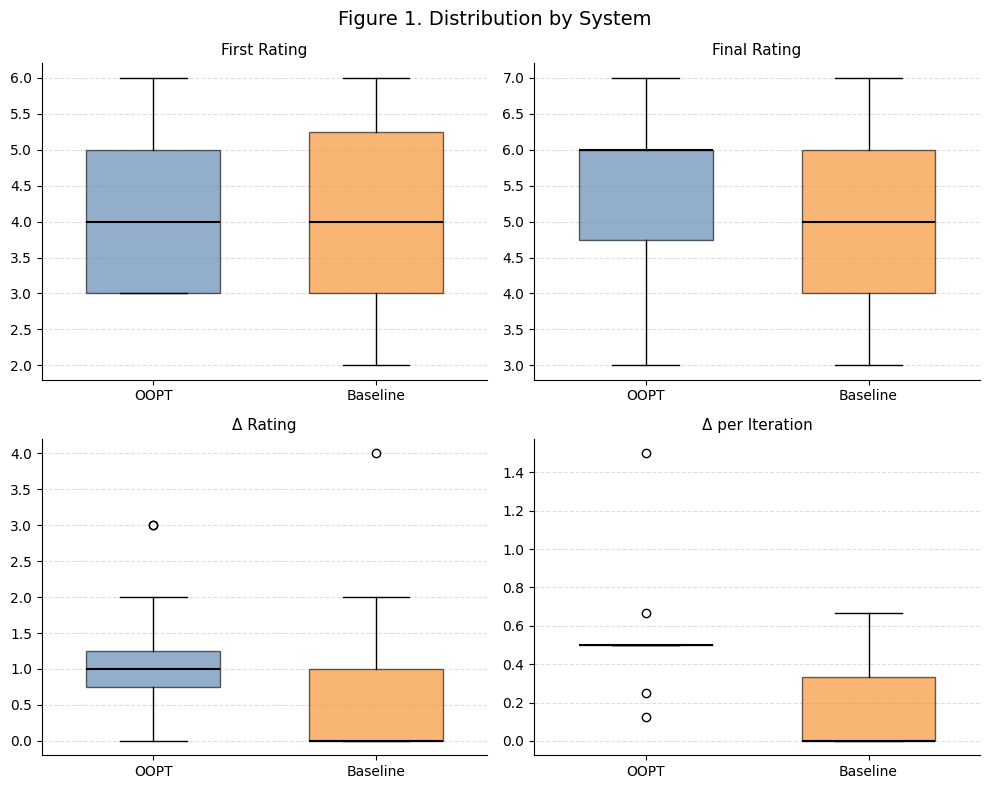

In [27]:
plot_figure1(merged)
